In [1]:
#
# Utility functions for CAB420, Assignment 1A, Q3
# Author: Simon Denman (s.denman@qut.edu.au)
#
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

from scipy.io import loadmat        # to load mat files
import matplotlib.pyplot as plt     # for plotting
import numpy as np                  # for reshaping, array manipulation
import cv2                          # for colour conversion
import tensorflow as tf             # for bulk image resize
import keras
from keras import layers

import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
# Load data for Q3
#  train_path: path to training data mat file
#  test_path:  path to testing data mat file
#
#  returns:    arrays for training and testing X and Y data
#
def load_data(train_path, val_path, test_path):

    # load files
    train = loadmat(train_path)
    val = loadmat(val_path)
    test = loadmat(test_path)

    # pull out training set and scale X data
    train_X = train['train_X'] / 255.0
    train_Y = train['train_y'].reshape(-1)

    # pull out validation set and scale X data
    val_X = val['val_X'] / 255.0
    val_Y = val['val_y'].reshape(-1)

    # pull out test set and scale X data
    test_X = test['test_X'] / 255.0
    test_Y = test['test_y'].reshape(-1)

    # return loaded data
    return train_X, train_Y, val_X, val_Y, test_X, test_Y

# vectorise an array of images, such that the shape is changed from {samples, width, height, channels} to
# (samples, width * height * channels)
#   images: array of images to vectorise
#
#   returns: vectorised array of images
#
def vectorise(images):
    # use numpy's reshape to vectorise the data
    return np.reshape(images, [len(images), -1])

# Plot some images and their labels. Will plot the first 100 samples in a 10x10 grid
#  x: array of images, of shape (samples, width, height, channels)
#  y: labels of the images
#
def plot_images(x, y):
    fig = plt.figure(figsize=[15, 18])
    for i in range(100):
        ax = fig.add_subplot(10, 10, i + 1)
        ax.imshow(x[i,:])
        ax.set_title(y[i])
        ax.axis('off')

# Resize an array of images
#  images:   array of images, of shape (samples, width, height, channels)
#  new_size: tuple of the new size, (new_width, new_height)
#
#  returns:  resized array of images, (samples, new_width, new_height, channels)
#
def resize(images, new_size):
    # tensorflow has an image resize funtion that can do this in bulk
    # note the conversion back to numpy after the resize
    return tf.image.resize(images, new_size).numpy()
          
# Convert images to grayscale
#   images:  array of colour images to convert, of size (samples, width, height, 3)
#
#   returns: array of converted images, of size (samples, width, height, 1)
#
def convert_to_grayscale(images):
    # storage for converted images
    gray = []
    # loop through images
    for i in range(len(images)):
        # convert each image using openCV
        gray.append(cv2.cvtColor(images[i,:], cv2.COLOR_BGR2GRAY))
    # pack converted list as an array and return
    return np.expand_dims(np.array(gray), axis = -1)

E0000 00:00:1744115132.807028 1032179 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744115132.810542 1032179 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Utility Function Demonstration

The following presents a brief demonstration of the utility functions. These portions of code do not form part of the template, or solution, and could be commented out/removed.

### Data Loading

Load the data, and visualise images.

(1000, 32, 32, 3)
(1000,)
(1000, 32, 32, 3)
(1000,)
(10000, 32, 32, 3)
(10000,)


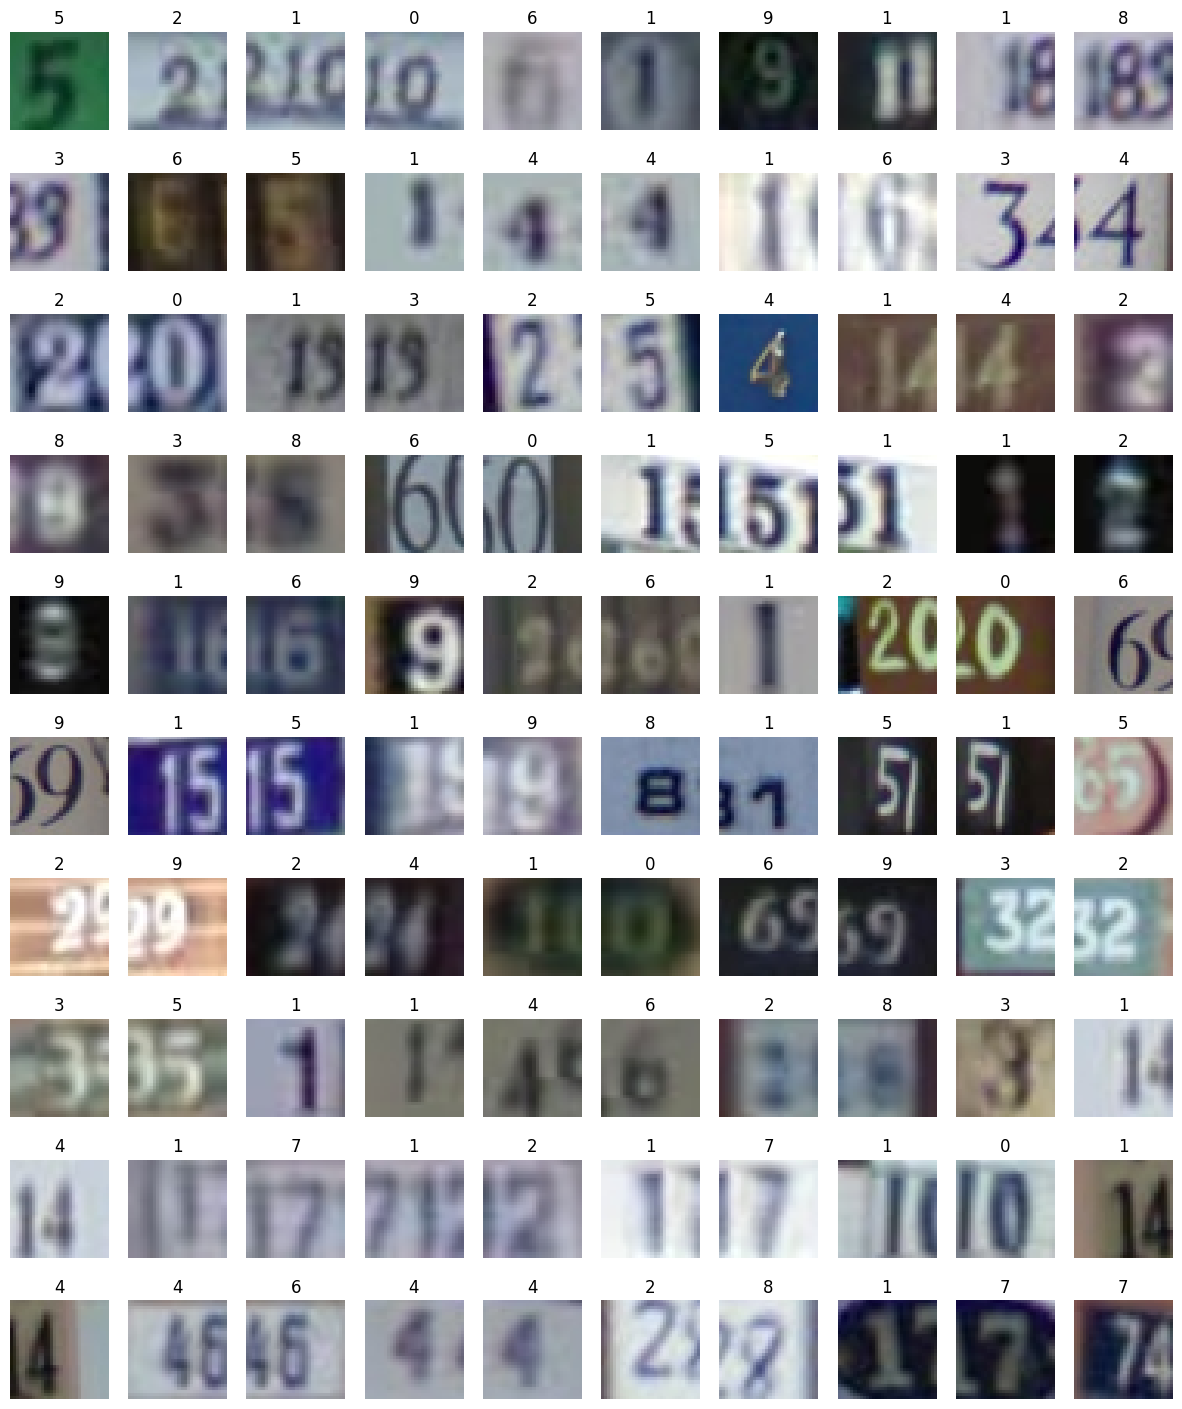

In [2]:
train_X, train_Y, val_X, val_Y, test_X, test_Y = load_data('CAB420_Assessment_1A_Data/Q3/q3_train.mat',
                                                           'CAB420_Assessment_1A_Data/Q3/q3_validation.mat', 
                                                           'CAB420_Assessment_1A_Data/Q3/q3_test.mat')

# check shape of data
print(train_X.shape)
print(train_Y.shape)
print(val_X.shape)
print(val_Y.shape)
print(test_X.shape)
print(test_Y.shape)

# visualise images as a sanity check
plot_images(train_X, train_Y)

### Vectorise Data

To train an SVM, each sample needs to be a vector rather than an image.

In [3]:
train_vector_X = vectorise(train_X)
val_vector_X = vectorise(val_X)
test_vector_X = vectorise(test_X)
print(train_vector_X.shape)
print(val_vector_X.shape)
print(test_vector_X.shape)

(1000, 3072)
(1000, 3072)
(10000, 3072)


### Conversion and Resizing

You may wish to either:
* Resize images
* Convert images to grayscale

Two functions are provided to do this, and can be used in combination as shown below.

I0000 00:00:1744115136.417406 1032179 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14236 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


(1000, 20, 20, 1)


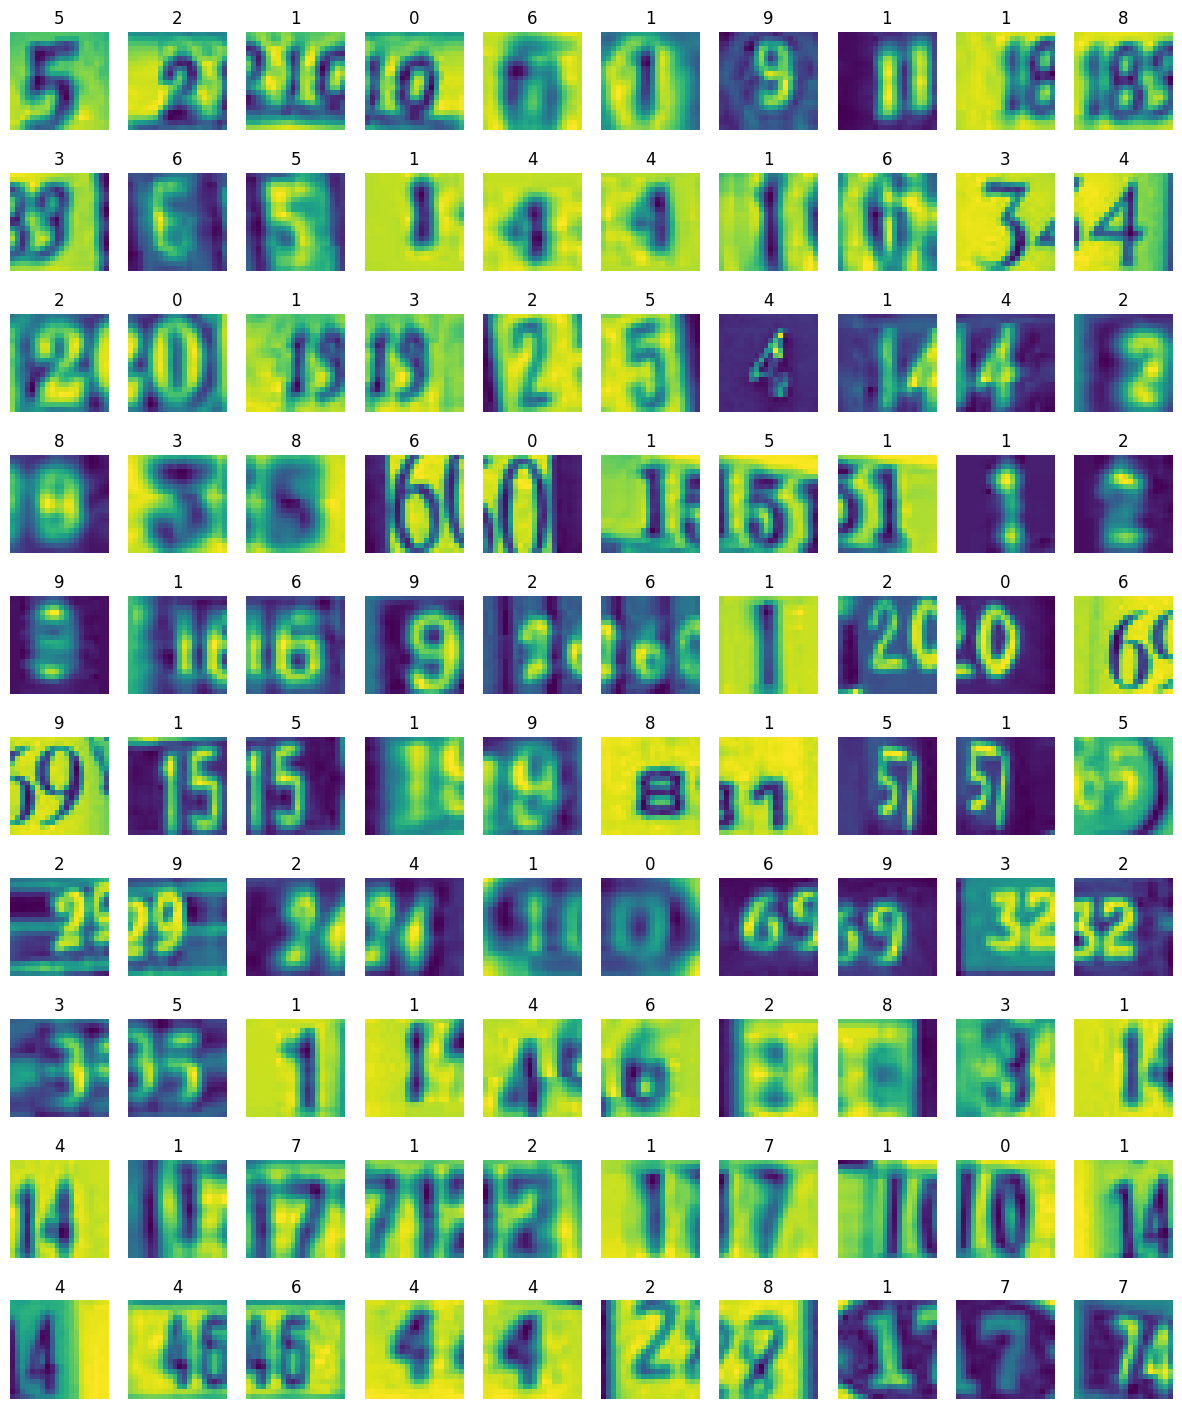

In [4]:
train_X_small = convert_to_grayscale(resize(train_X, (20, 20)))
print(train_X_small.shape)
plot_images(train_X_small, train_Y)

### Measuring Time

There are a lot of ways to measure time in python. A simple one is to use ``process_time`` within the ``time`` package. This will simply measure the ellapsed process time in seconds. We can use ths to measure individual parts of our code as follows:

In [5]:
# import process_time
from time import process_time

# get a start time
time_1 = process_time()

# do some stuff, in this case we'll just load some data
train_X, train_Y,val_X, val_Y, test_X, test_Y = load_data('CAB420_Assessment_1A_Data/Q3/q3_train.mat',
                                                          'CAB420_Assessment_1A_Data/Q3/q3_validation.mat',
                                                          'CAB420_Assessment_1A_Data/Q3/q3_test.mat')

# get the end time of our first lot of "stuff"
time_2 = process_time()

# do some other stuff
train_X_small = convert_to_grayscale(resize(train_X, (20, 20)))

# get the end time of our first lot of "stuff"
time_3 = process_time()

# the time it took to do "our stuff" is just the difference between the start and end times
print('Time to load data:   %f seconds' % (time_2 - time_1))
print('Time to resize data: %f seconds' % (time_3 - time_2))

Time to load data:   0.065382 seconds
Time to resize data: 0.024236 seconds


## Question 3 Template

The following provides a starting point for your solution. It trains the SVM that you are to compare your trained DCNNs against, and measures the time taken to train this SVM, and to perform inference with the train and test sets.

This does not measure the performance of the SVM - you will need to implement this as part of your solution.

Training Time: 1.496261
Inference Time (training set): 0.673046
Inference Time (testing set): 6.593101

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.89      0.84      0.87        70
           1       0.65      0.93      0.77       185
           2       0.74      0.82      0.78       164
           3       0.88      0.76      0.81       115
           4       0.92      0.75      0.83        92
           5       0.92      0.86      0.89        83
           6       0.95      0.84      0.89        86
           7       0.85      0.73      0.79        79
           8       1.00      0.72      0.83        60
           9       0.94      0.71      0.81        66

    accuracy                           0.81      1000
   macro avg       0.87      0.80      0.83      1000
weighted avg       0.84      0.81      0.82      1000


Classification Report (Test Set):
              precision    recall  f1-score   support

         

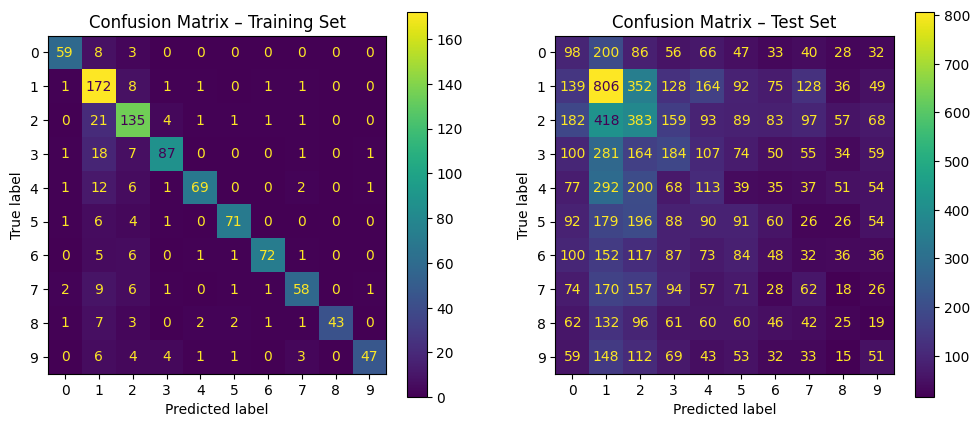

In [6]:
from sklearn.svm import SVC
from time import process_time
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# load data
train_X, train_Y,val_X, val_Y, test_X, test_Y = load_data('CAB420_Assessment_1A_Data/Q3/q3_train.mat',
                                                          'CAB420_Assessment_1A_Data/Q3/q3_validation.mat',
                                                          'CAB420_Assessment_1A_Data/Q3/q3_test.mat')

# any resize, colour change, etc, would go here
# if you do anything, do the same thing to the training, validation, and test sets

# vectorise data
# If you do any resize, reshape, etc of the data prior to putting this into your DCNN, change this code to 
# vectorise that verison of the data. The same data should be used by all models for a fair comparison; though
# you will only vectorise the data for the SVM (i.e. the DCNN will get the data as images).
train_vector_X = vectorise(train_X)
val_vector_X = vectorise(val_X)
test_vector_X = vectorise(test_X)

# train the SVM
# Note that you are not required to tune the SVM, just use it as it is. This also means that we do not need the validation
# set for the SVM as we're not selecting hyper-parameters
# measure the start time of training
svm_train_start = process_time()
# run the training - note that you don't need to change any parameters here except potentially for the input data is you 
# resize, change colour, etc
svm = SVC(C = 1.0, kernel = 'linear').fit(train_vector_X, train_Y)
# record the end time of the training
svm_train_end = process_time()
# predict on the training set
train_predictions = svm.predict(train_vector_X)
# measure of the time of the training set prediction
svm_train_pred_end = process_time()
# predict on the test set
test_predictions = svm.predict(test_vector_X)
# measure the end time on the prediction of the test set
svm_test_pred_end = process_time()

# check how long the SVM took to train
svm_train_time = svm_train_end - svm_train_start
# check how long the SVM took to perform inference on the training set
svm_inference_train_time = svm_train_pred_end - svm_train_end
# check how long the SVM took to perform inference on the testing set
svm_inference_test_time = svm_test_pred_end - svm_train_pred_end
# print some times
print('Training Time: %f\nInference Time (training set): %f\nInference Time (testing set): %f' % \
      (svm_train_time, svm_inference_train_time, svm_inference_test_time))

# evaluate SVM
# here you can insert whatever evaluation metrics you feel are appropriate, though F1 and a confusion matrix would be a fair
# option



# evaluate SVM
print("\nClassification Report (Training Set):")
print(classification_report(train_Y, train_predictions))

print("\nClassification Report (Test Set):")
print(classification_report(test_Y, test_predictions))

# plot confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(svm, train_vector_X, train_Y, ax=ax[0])
ax[0].set_title('Confusion Matrix – Training Set')
ConfusionMatrixDisplay.from_estimator(svm, test_vector_X, test_Y, ax=ax[1])
ax[1].set_title('Confusion Matrix – Test Set')
plt.show()

In [7]:
# develop, evaluate and compare DCNNs
#
# You should create one DCNN which you will train from scratch, and then add augmentation to this and train it again.
# Use whatever augmentation you feel is appropraite.
#
# For your DCNN design, feel free to borrow networks from pracs and lecture examples. The network does not need to be
# overly complex, but you should briefly explain your selection of this model. You should avoid networks so simple 
# that they perform very badly. Look at the lecture notes and the sort of simple DCNNs we've created as a guide. With 
# respect to training time, there is no minimum or maximum training time, but you should either:
#  - Train both your models to convergence, noting that this may take different numbers of epochs
#  - Train your networks for the same period of time, ensuring that this time is sufficient for at least one to converge
# Keep in mind that with the very small training set, you may need to increase the number of epochs compared to what we
# see in the lecture examples

# do some stuff, in this case we'll just load some data

train_X, train_Y,val_X, val_Y, test_X, test_Y = load_data('CAB420_Assessment_1A_Data/Q3/q3_train.mat',
                                                          'CAB420_Assessment_1A_Data/Q3/q3_validation.mat',
                                                          'CAB420_Assessment_1A_Data/Q3/q3_test.mat')


train_X_small = convert_to_grayscale(resize(train_X, (28, 28)))
val_X_small = convert_to_grayscale(resize(val_X, (28, 28)))
test_X_small = convert_to_grayscale(resize(test_X, (28, 28)))


# our input now has a different shape, 28x28x1, as we have 28x28 single channel images
inputs = keras.Input(shape=(28, 28, 1, ), name='img')
# rather than use a fully connected layer, we'll use 2D convolutional layers, 8 filters, 3x3 size kernels
x = layers.Conv2D(filters=8, kernel_size=(3,3), activation='relu')(inputs)
# 2x2 max pooling, this will downsample the image by a factor of two
x = layers.MaxPool2D(pool_size=(2, 2))(x)
# more convolution, 16 filters, followed by max poool
x = layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu')(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
# final convolution, 32 filters
x = layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu')(x)
# a flatten layer. Matlab does a flatten automatically, here we need to explicitly do this. Basically we're telling
# keras to make the current network state into a 1D shape so we can pass it into a fully connected layer
x = layers.Flatten()(x)
# a single fully connected layer, 64 inputs
x = layers.Dense(64, activation='relu')(x)
# and now our output, same as last time
outputs = layers.Dense(10, activation='softmax')(x)

# build the model, and print the summary
model_cnn = keras.Model(inputs=inputs, outputs=outputs, name='CNN')
model_cnn.summary()





Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img (InputLayer)                │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,034 (97.79 KB)

 Trainable params: 25,034 (97.79 KB)

 Non-trainable params: 0 (0.00 B)

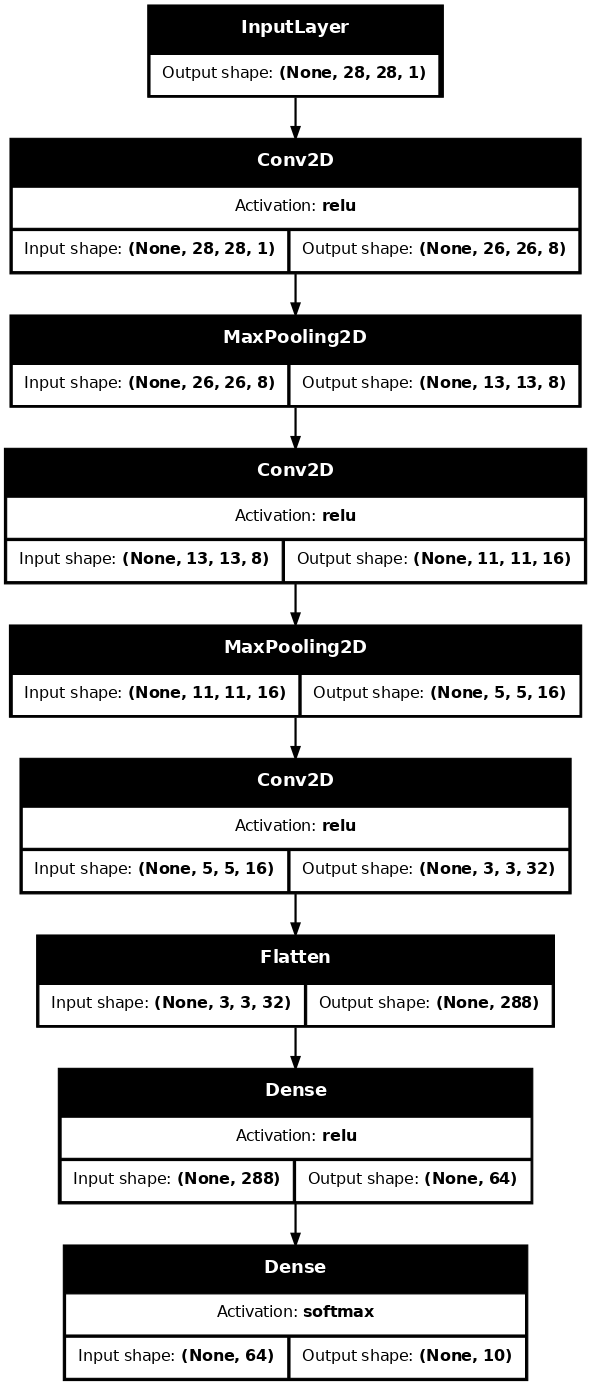

In [8]:
keras.utils.plot_model(model_cnn, show_shapes=True, dpi=80, show_layer_activations=True)



In [9]:
# def eval_model(model, history, x_test, y_test):
#     test_scores = model.evaluate(x_test, y_test, verbose=0)
#     print('Test loss:', test_scores[0])
#     print('Test accuracy:', test_scores[1])

#     pred = model.predict(x_test, verbose=False);
#     indexes = keras.ops.argmax(pred, axis=1)
    
#     cm = confusion_matrix(y_test, indexes)
#     fig = plt.figure(figsize=[8, 8])
#     ax = fig.add_subplot(1, 1, 1)
#     c = ConfusionMatrixDisplay(cm, display_labels=range(10))
#     c.plot(ax = ax)
    
#     print(classification_report(y_test, indexes))

#     fig = plt.figure(figsize=[8, 4])
#     ax = fig.add_subplot(1, 1, 1)
#     ax.plot(history['loss'], label='Training Loss')
#     ax.plot(history['accuracy'], label='Training Accuracy')
#     ax.plot(history['val_loss'], label='Validation Loss')
#     ax.plot(history['val_accuracy'], label='Validation Accuracy')
#     ax.set_xlabel('Training Epochs')
#     ax.set_ylabel('Accuracy or Loss')
#     ax.legend()

def eval_model(model, history, x_train, y_train, x_test, y_test):
    # Evaluate on test set
    test_scores = model.evaluate(x_test, y_test, verbose=0)
    print('Test loss:', test_scores[0])
    print('Test accuracy:', test_scores[1])

    # Predictions for test
    pred_test = model.predict(x_test, verbose=False)
    pred_test_classes = keras.ops.argmax(pred_test, axis=1)
    acc_test = accuracy_score(y_test, pred_test_classes)
    f1_test = f1_score(y_test, pred_test_classes, average='macro')
    print(f"\nTest Accuracy: {acc_test:.4f}")
    print(f"Test F1 Score (macro): {f1_test:.4f}")
    print("\nTest Classification Report:\n", classification_report(y_test, pred_test_classes))

    # Predictions for training
    pred_train = model.predict(x_train, verbose=False)
    pred_train_classes = keras.ops.argmax(pred_train, axis=1)
    acc_train = accuracy_score(y_train, pred_train_classes)
    f1_train = f1_score(y_train, pred_train_classes, average='macro')
    print(f"\nTrain Accuracy: {acc_train:.4f}")
    print(f"Train F1 Score (macro): {f1_train:.4f}")
    print("\nTrain Classification Report:\n", classification_report(y_train, pred_train_classes))

    # Confusion Matrix - Training
    cm_train = confusion_matrix(y_train, pred_train_classes)
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    ConfusionMatrixDisplay(cm_train).plot(ax=ax[0], cmap='Blues')
    ax[0].set_title(f'Training Confusion Matrix\nAccuracy: {acc_train:.4f} | F1 Score: {f1_train:.4f}')

    # Confusion Matrix - Testing
    cm_test = confusion_matrix(y_test, pred_test_classes)
    ConfusionMatrixDisplay(cm_test).plot(ax=ax[1], cmap='Greens')
    ax[1].set_title(f'Test Confusion Matrix\nAccuracy: {acc_test:.4f} | F1 Score: {f1_test:.4f}')

    plt.tight_layout()
    plt.show()

    # Training curves
    fig = plt.figure(figsize=[8, 4])
    ax = fig.add_subplot(1, 1, 1)
    ax.plot(history['loss'], label='Training Loss')
    ax.plot(history['accuracy'], label='Training Accuracy')
    ax.plot(history['val_loss'], label='Validation Loss')
    ax.plot(history['val_accuracy'], label='Validation Accuracy')
    ax.set_xlabel('Training Epochs')
    ax.set_ylabel('Accuracy or Loss')
    ax.legend()
    ax.set_title('Training and Validation Curves')
    plt.tight_layout()
    plt.show()


In [10]:
model_cnn.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  optimizer=keras.optimizers.Adam(),
                  metrics=['accuracy'], jit_compile=False)
history = model_cnn.fit(train_X_small, train_Y,
                        batch_size=64,
                        epochs=45,
                        validation_data=(val_X_small, val_Y))


Epoch 1/45


I0000 00:00:1744115156.290926 1032387 cuda_dnn.cc:529] Loaded cuDNN version 90300


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1296 - loss: 2.2834 - val_accuracy: 0.1930 - val_loss: 2.2459
Epoch 2/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1666 - loss: 2.2494 - val_accuracy: 0.1890 - val_loss: 2.2467
Epoch 3/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1867 - loss: 2.2426 - val_accuracy: 0.1930 - val_loss: 2.2347
Epoch 4/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1855 - loss: 2.2129 - val_accuracy: 0.2060 - val_loss: 2.2321
Epoch 5/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2409 - loss: 2.1946 - val_accuracy: 0.1940 - val_loss: 2.2162
Epoch 6/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2057 - loss: 2.1663 - val_accuracy: 0.2030 - val_loss: 2.1881
Epoch 7/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2296 - loss: 2.1406 - val_accuracy: 0.2360 - val_loss: 2.1608
Epoch 8/45
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2565 - loss: 2.1003 - val_accuracy: 0.2240 - val_loss: 2.1092
Ep

Test loss: 1.2233545780181885
Test accuracy: 0.6651999950408936

Test Accuracy: 0.6652
Test F1 Score (macro): 0.6273

Test Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.60      0.57       686
           1       0.79      0.82      0.81      1969
           2       0.73      0.79      0.76      1629
           3       0.59      0.58      0.59      1108
           4       0.76      0.66      0.71       966
           5       0.69      0.62      0.65       902
           6       0.54      0.62      0.58       765
           7       0.83      0.47      0.60       757
           8       0.43      0.50      0.46       603
           9       0.53      0.56      0.54       615

    accuracy                           0.67     10000
   macro avg       0.64      0.62      0.63     10000
weighted avg       0.68      0.67      0.67     10000


Train Accuracy: 0.8630
Train F1 Score (macro): 0.8512

Train Classification Report:
         

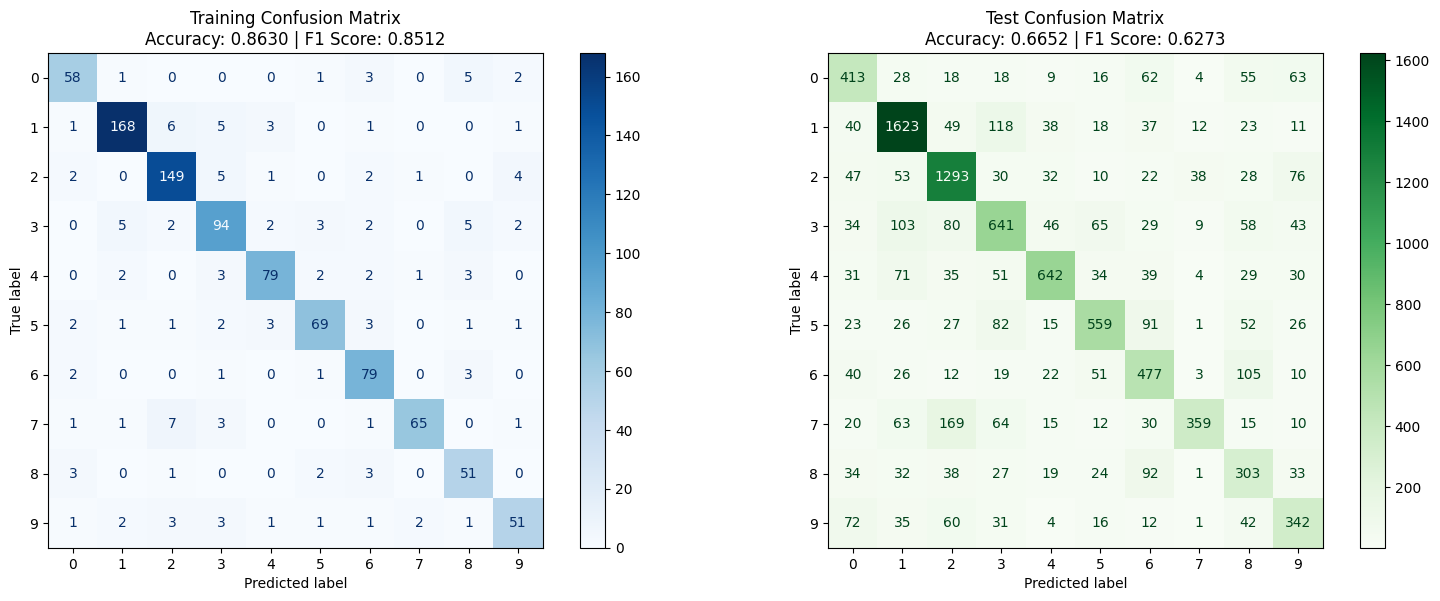

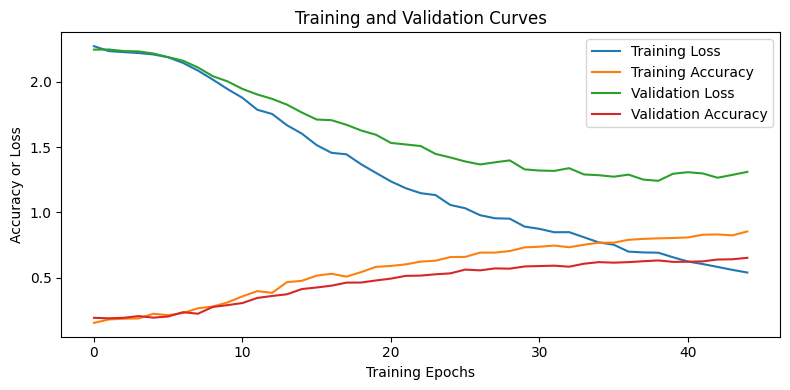

In [11]:


eval_model(model_cnn, history.history, train_X_small, train_Y, test_X_small, test_Y)

#  eval_model(model_cnn, history.history, test_X_small, test_Y)



In [12]:
# Data Augmentation

data_augmentation = keras.Sequential([
    layers.Rescaling(1./255),  # Normalize pixel values
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.025),
    layers.RandomTranslation(height_factor=0.025, width_factor=0.025)
], name='data_augmentation')



inputs = keras.Input(shape=(28, 28, 1), name='img')
x = data_augmentation(inputs)  # 👈 apply augmentation here

# Your CNN layers continue
x = layers.Conv2D(filters=8, kernel_size=(3, 3), activation='relu')(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu')(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)

model_cnn_AUG = keras.Model(inputs=inputs, outputs=outputs, name='CNN_with_augmentation')

model_cnn_AUG.summary()


Model: "CNN_with_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img (InputLayer)                │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,034 (97.79 KB)

 Trainable params: 25,034 (97.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1134 - loss: 2.2995 - val_accuracy: 0.1930 - val_loss: 2.2837
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1860 - loss: 2.2720 - val_accuracy: 0.1930 - val_loss: 2.2446
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1778 - loss: 2.2430 - val_accuracy: 0.1930 - val_loss: 2.2434
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1893 - loss: 2.2366 - val_accuracy: 0.1930 - val_loss: 2.2418
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1712 - loss: 2.2431 - val_accuracy: 0.1930 - val_loss: 2.2425
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1834 - loss: 2.2294 - val_accuracy: 0.1930 - val_loss: 2.2434
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1740 - loss: 2.2409 - val_accuracy: 0.1930 - val_loss: 2.2412
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1789 - loss: 2.2384 - val_accuracy: 0.1930 - 

/home/omar/miniforge3/envs/cab420/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/omar/miniforge3/envs/cab420/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/omar/miniforge3/envs/cab420/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

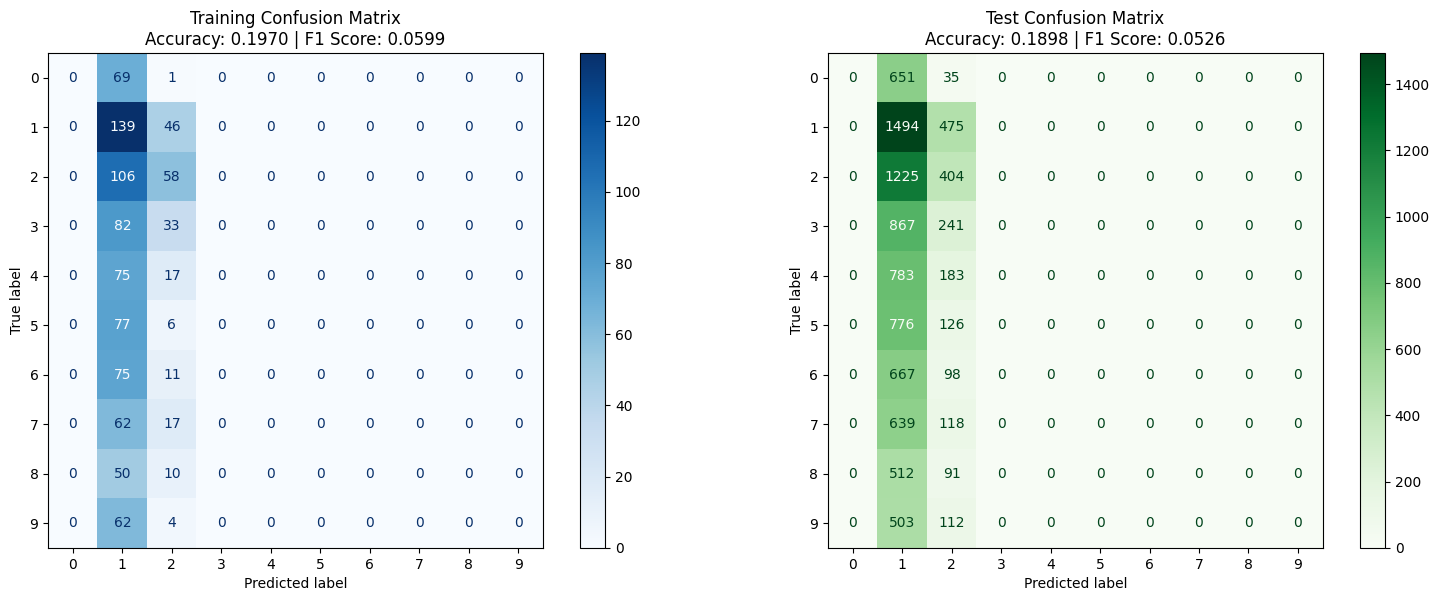

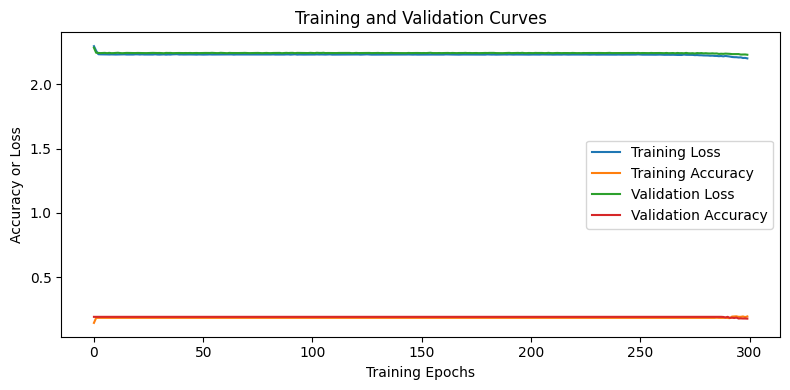

In [13]:
model_cnn_AUG.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  optimizer=keras.optimizers.Adam(),
                  metrics=['accuracy'], jit_compile=False)
history = model_cnn_AUG.fit(train_X_small, train_Y,
                        batch_size=64,
                        epochs=300,
                        validation_data=(val_X_small, val_Y))

eval_model(model_cnn_AUG, history.history, train_X_small, train_Y, test_X_small, test_Y)
